# Querying ACE Routes

Objectives:

1. Gather data on vioalations
2. Gather data based on
   - Buses
   - Boroughs
   - Time periods
3. Summarize findings


## Setup & Prerequisites


In [77]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..", "..")))

import pandas as pd  # data wrangler library, dataframes are used to display and manipulate data
import seaborn as sns  # data graphing library, built on top of matplotlib
import matplotlib.pyplot as plt  # graphing library, used for titles and customization
import urllib.parse  # library to parse URLs for querying
import folium  # library to create interactive maps
import folium.plugins as plugins  # plugins for folium, used for clustering map points
import geopandas as gpd  # library to handle geospatial data
from notebooks.utils.utils import SOQL_Querying  # soql query object for help
from scipy import stats

## Violation Summaries


In [2]:
# Summary query object made for ease of use

qo = SOQL_Querying()

In [ ]:
violation_columns = qo.query(
    api="violations",
    query="""
    select
    *
    limit
    1
    """,
)
violations_columns_df = pd.read_csv(violation_columns)  # type: ignore
violations_columns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   violation_id            1 non-null      int64  
 1   vehicle_id              1 non-null      object 
 2   first_occurrence        1 non-null      object 
 3   last_occurrence         1 non-null      object 
 4   violation_status        1 non-null      object 
 5   violation_type          1 non-null      object 
 6   bus_route_id            1 non-null      object 
 7   violation_latitude      1 non-null      float64
 8   violation_longitude     1 non-null      float64
 9   stop_id                 1 non-null      int64  
 10  stop_name               1 non-null      object 
 11  bus_stop_latitude       1 non-null      float64
 12  bus_stop_longitude      1 non-null      float64
 13  violation_georeference  1 non-null      object 
 14  bus_stop_georeference   1 non-null      object

In [8]:
violations_columns_df.head()

,violation_id,vehicle_id,first_occurrence,last_occurrence,violation_status,violation_type,bus_route_id,violation_latitude,violation_longitude,stop_id,stop_name,bus_stop_latitude,bus_stop_longitude,violation_georeference,bus_stop_georeference
0,509829432,e40f5a553e9ee2e9b50c7affe9cdbb6bb89a1e04c4b3fc...,2025-12-04T13:35:20.000,2025-12-04T13:40:22.000,TECHNICAL ISSUE/OTHER,MOBILE BUS STOP,BX36,40.849043,-73.93304,403652,W 181 ST/AMSTERDAM AV,40.848237,-73.931,POINT (-73.93304 40.849043),POINT (-73.931 40.848237)


### Summaries of violation types and statuses in 2025


In [ ]:
violations_2025 = qo.query(
    api="violations",
    query="""
    select
    violation_status,
    violation_type,
    count(violation_type) as violations
    where
    date_extract_y(first_occurrence) = 2025
    group by
    violation_status,
    violation_type
    order by
    violation_status desc,
    violations desc
    """,
)
violations_2025_df = pd.read_csv(violations_2025)  # type: ignore
violations_2025_df.dropna(axis=0, inplace=True)
violations_2025_df.head(35)

,violation_status,violation_type,violations
3,VIOLATION ISSUED,MOBILE BUS STOP,586154
4,VIOLATION ISSUED,MOBILE DOUBLE PARKED,559417
5,VIOLATION ISSUED,MOBILE BUS LANE,197014
6,TECHNICAL ISSUE/OTHER,MOBILE BUS STOP,107039
7,TECHNICAL ISSUE/OTHER,MOBILE DOUBLE PARKED,99429
8,TECHNICAL ISSUE/OTHER,MOBILE BUS LANE,23880
9,EXEMPT - OTHER,MOBILE BUS STOP,43745
10,EXEMPT - OTHER,MOBILE DOUBLE PARKED,32664
11,EXEMPT - OTHER,MOBILE BUS LANE,23922
12,EXEMPT - EMERGENCY VEHICLE,MOBILE BUS STOP,103867


In [35]:
violations_2025_df.describe()

,violations
count,21.000000
mean,116188.952381
std,161510.542801
min,7730.000000
25%,32664.000000
50%,62213.000000
75%,103867.000000
max,586154.000000


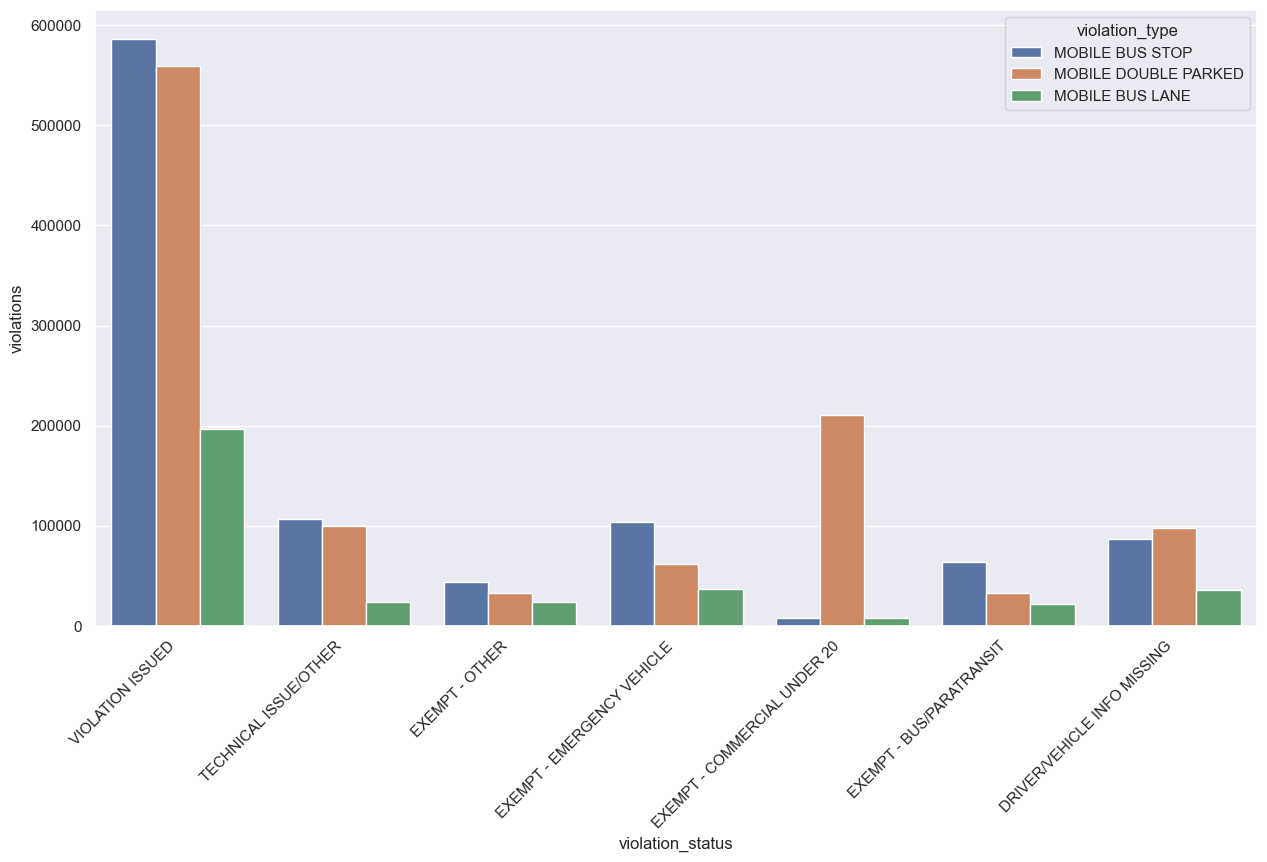

In [ ]:
sns.set_theme()

plt.figure(figsize=(15, 8))
sns.barplot(
    data=violations_2025_df, x="violation_status", y="violations", hue="violation_type"
)
plt.xticks(rotation=45, ha="right")
plt.show()

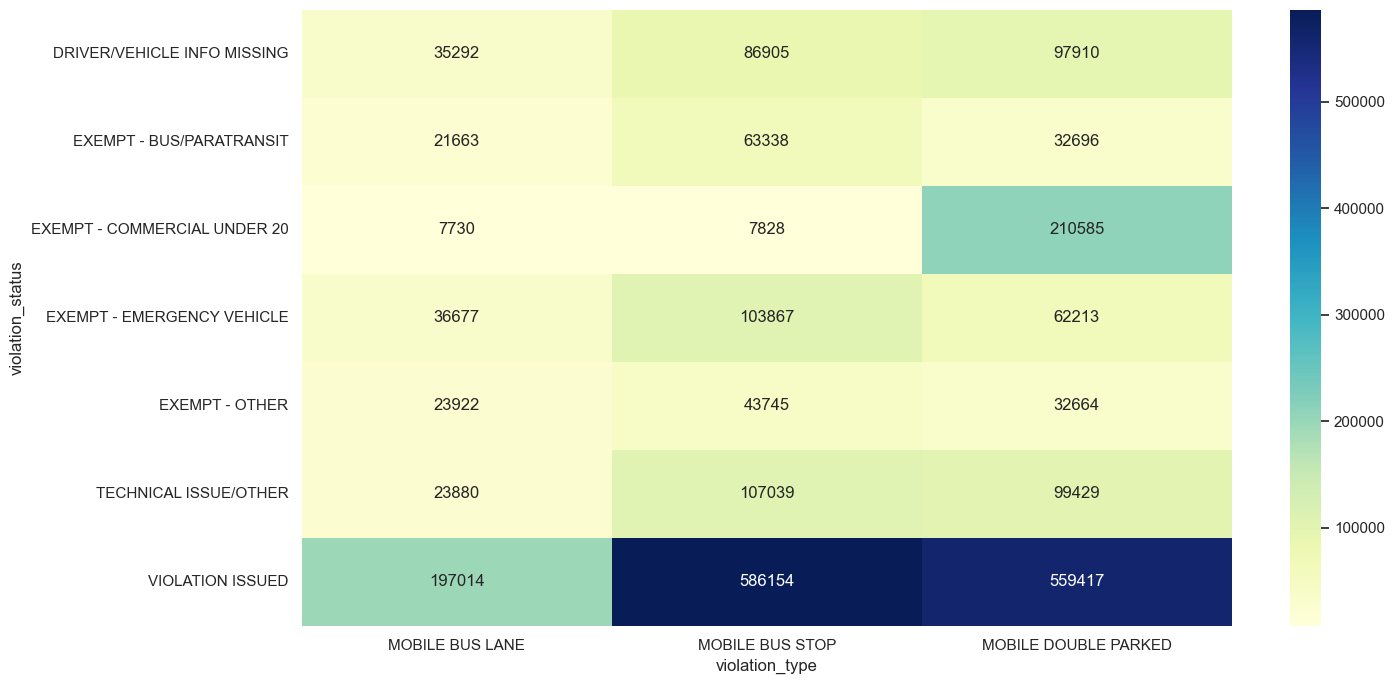

In [ ]:
plt.figure(figsize=(15, 8))
pivot_df = violations_2025_df.pivot(
    index="violation_status", columns="violation_type", values="violations"
)
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu")
plt.show()

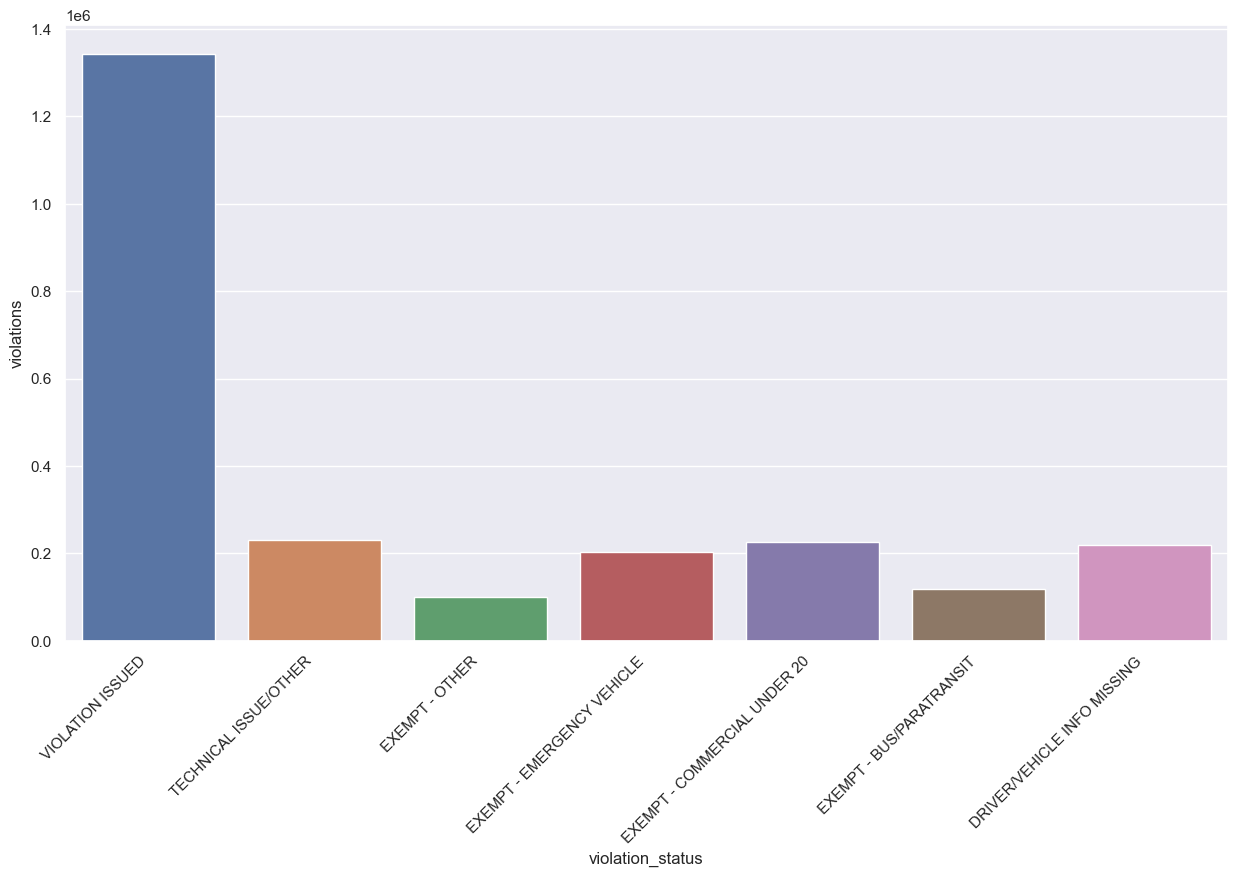

In [ ]:
plt.figure(figsize=(15, 8))
sns.barplot(
    data=violations_2025_df,
    x="violation_status",
    y="violations",
    estimator=sum,
    errorbar=None,
    hue="violation_status",
)
plt.xticks(rotation=45, ha="right")
plt.show()

### Summaries of violations by buses and boroughs


In [49]:
violations_buses = qo.query(
    api="violations",
    query="""
    select
    bus_route_id,
    violation_status,
    violation_type,
    count(violation_type) as violations
    where
    date_extract_y(first_occurrence) = 2025
    group by
    bus_route_id,
    violation_status,
    violation_type
    order by
    violations desc
    """,
)
violations_buses_df = pd.read_csv(violations_buses)  # type: ignore
violations_buses_df.dropna(axis=0, inplace=True)
violations_buses_df.head(35)

,bus_route_id,violation_status,violation_type,violations
0,BX19,VIOLATION ISSUED,MOBILE DOUBLE PARKED,74749
1,M101,VIOLATION ISSUED,MOBILE BUS STOP,64519
2,M101,VIOLATION ISSUED,MOBILE DOUBLE PARKED,59472
3,M100,VIOLATION ISSUED,MOBILE DOUBLE PARKED,55477
4,M15+,VIOLATION ISSUED,MOBILE BUS STOP,49793
5,BX36,VIOLATION ISSUED,MOBILE DOUBLE PARKED,49331
6,B35,VIOLATION ISSUED,MOBILE BUS STOP,41583
7,BX19,VIOLATION ISSUED,MOBILE BUS STOP,33241
8,M101,VIOLATION ISSUED,MOBILE BUS LANE,30447
9,B82+,VIOLATION ISSUED,MOBILE BUS STOP,30192


In [50]:
def get_borough(route):
    # Check 'Bx' first because 'B' is a substring of 'Bx'
    if route.startswith("BX"):
        return "Bronx"
    elif route.startswith("B"):
        return "Brooklyn"
    elif route.startswith("M"):
        return "Manhattan"
    elif route.startswith("Q"):
        return "Queens"
    elif route.startswith("S"):
        return "Staten Island"
    else:
        return "Other"


violations_buses_df["borough"] = violations_buses_df["bus_route_id"].apply(get_borough)

In [51]:
violations_buses_df.head(10)

,bus_route_id,violation_status,violation_type,violations,borough
0,BX19,VIOLATION ISSUED,MOBILE DOUBLE PARKED,74749,Bronx
1,M101,VIOLATION ISSUED,MOBILE BUS STOP,64519,Manhattan
2,M101,VIOLATION ISSUED,MOBILE DOUBLE PARKED,59472,Manhattan
3,M100,VIOLATION ISSUED,MOBILE DOUBLE PARKED,55477,Manhattan
4,M15+,VIOLATION ISSUED,MOBILE BUS STOP,49793,Manhattan
5,BX36,VIOLATION ISSUED,MOBILE DOUBLE PARKED,49331,Bronx
6,B35,VIOLATION ISSUED,MOBILE BUS STOP,41583,Brooklyn
7,BX19,VIOLATION ISSUED,MOBILE BUS STOP,33241,Bronx
8,M101,VIOLATION ISSUED,MOBILE BUS LANE,30447,Manhattan
9,B82+,VIOLATION ISSUED,MOBILE BUS STOP,30192,Brooklyn


<Axes: xlabel='borough', ylabel='count'>

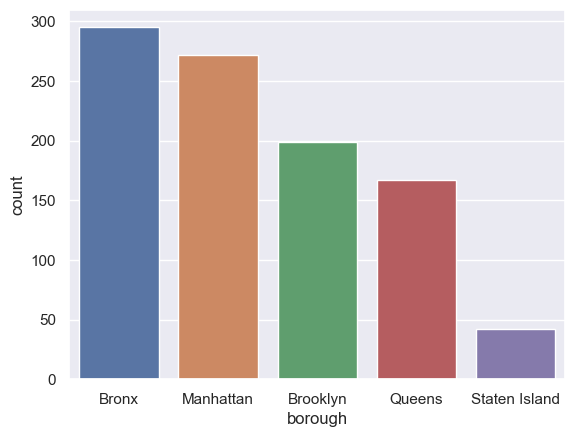

In [52]:
sns.countplot(data=violations_buses_df, x="borough", hue="borough")

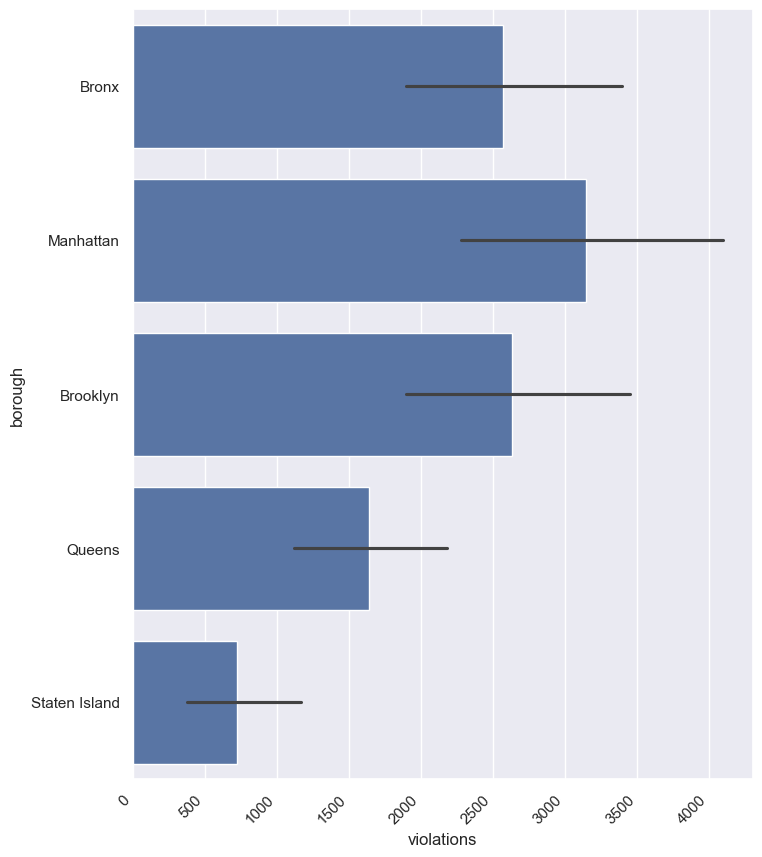

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(data=violations_buses_df, x="violations", y="borough")
plt.xticks(rotation=45, ha="right")
plt.show()

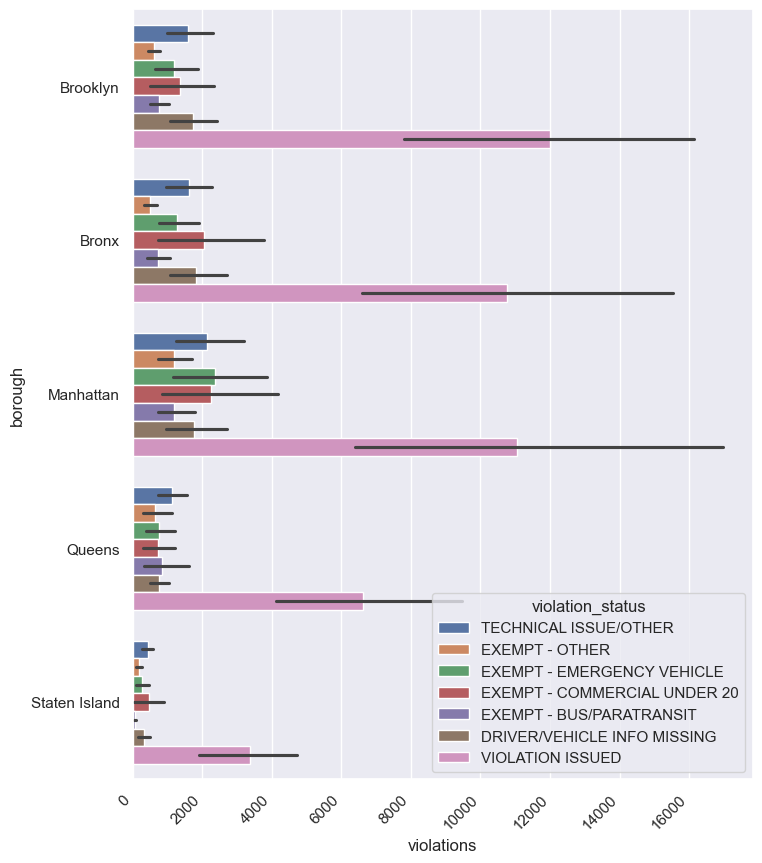

In [45]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=violations_buses_df, x="violations", y="borough", hue="violation_status"
)
plt.xticks(rotation=45, ha="right")
plt.show()

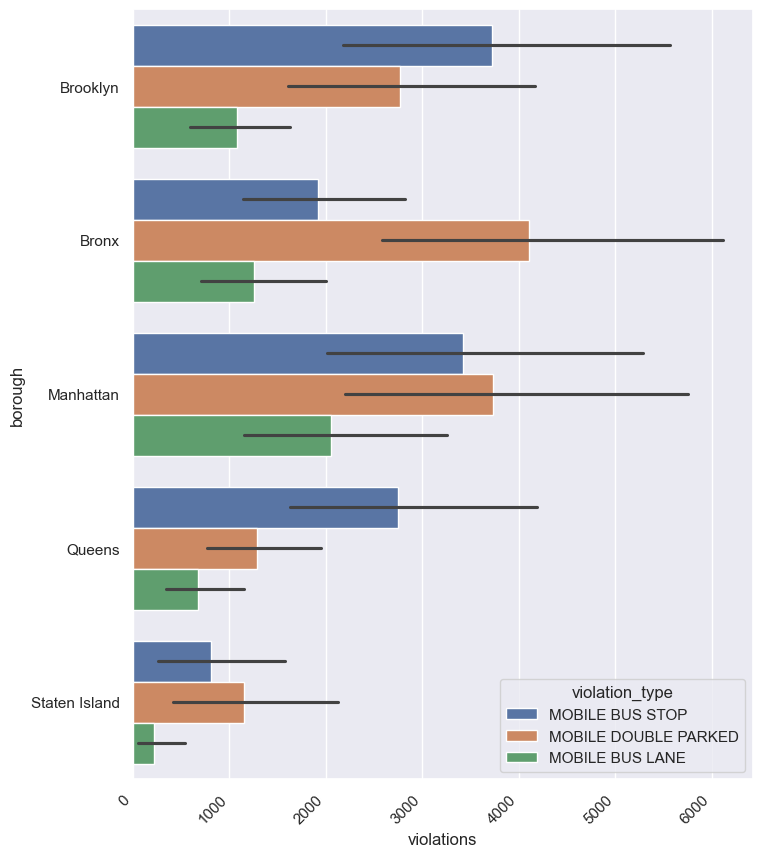

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(data=violations_buses_df, x="violations", y="borough", hue="violation_type")
plt.xticks(rotation=45, ha="right")
plt.show()

In [53]:
violations_buses_df.head()

,bus_route_id,violation_status,violation_type,violations,borough
0,BX19,VIOLATION ISSUED,MOBILE DOUBLE PARKED,74749,Bronx
1,M101,VIOLATION ISSUED,MOBILE BUS STOP,64519,Manhattan
2,M101,VIOLATION ISSUED,MOBILE DOUBLE PARKED,59472,Manhattan
3,M100,VIOLATION ISSUED,MOBILE DOUBLE PARKED,55477,Manhattan
4,M15+,VIOLATION ISSUED,MOBILE BUS STOP,49793,Manhattan


In [ ]:
violations_buses_totals = (
    violations_buses_df.groupby("bus_route_id")["violations"].sum().reset_index()
)
violations_buses_totals.sort_values(by="violations", inplace=True, ascending=False)
violations_buses_totals.head()

,bus_route_id,violations
31,M101,304542
14,BX19,201262
34,M15+,171205
22,BX36,139027
3,B35,110273


In [ ]:
violations_buses_totals["borough"] = violations_buses_totals["bus_route_id"].apply(
    get_borough
)
violations_buses_totals.head()

,bus_route_id,violations,borough
31,M101,304542,Manhattan
14,BX19,201262,Bronx
34,M15+,171205,Manhattan
22,BX36,139027,Bronx
3,B35,110273,Brooklyn


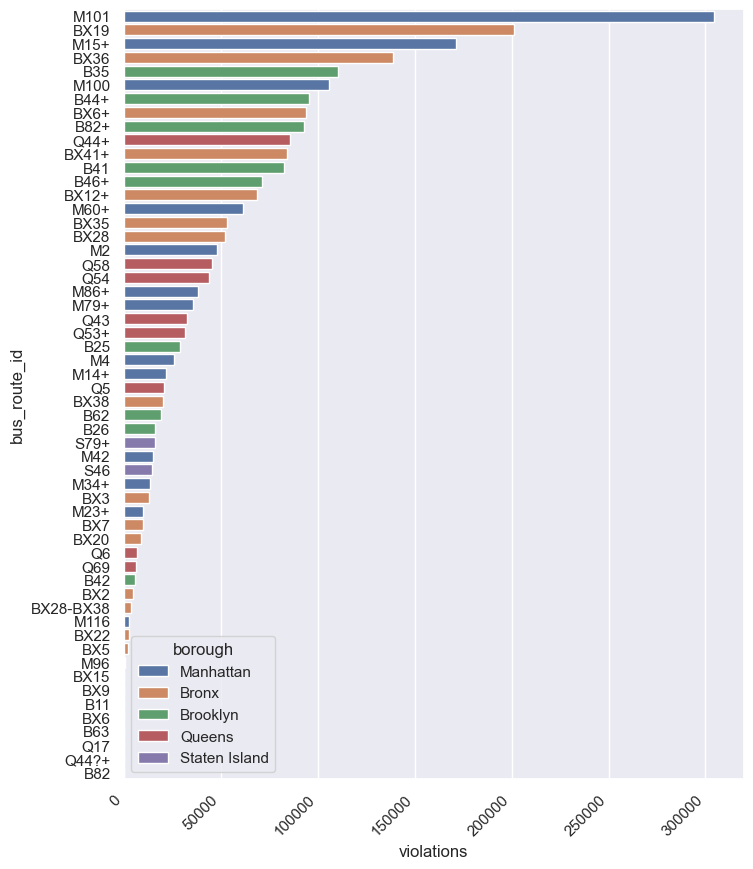

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=violations_buses_totals, y="bus_route_id", x="violations", hue="borough"
)
plt.xticks(rotation=45, ha="right")
plt.show()

### Summaries of violations and time periods


In [ ]:
violations_quarters = qo.query(
    api="violations",
    query="""
    SELECT
        CASE(
            date_extract_m(first_occurrence) BETWEEN 1 AND 3, 'Q1',
            date_extract_m(first_occurrence) BETWEEN 4 AND 6, 'Q2',
            date_extract_m(first_occurrence) BETWEEN 7 AND 9, 'Q3',
            date_extract_m(first_occurrence) BETWEEN 10 AND 12, 'Q4'
        ) AS quarter,
        violation_status,
        violation_type,
        count(violation_type) AS violations
    WHERE
    date_extract_y(first_occurrence) = 2025
    GROUP BY
        quarter,
        violation_status,
        violation_type
    ORDER BY
        quarter asc,
        violation_status asc,
        violation_type asc
    """,
)
violations_quarters_df = pd.read_csv(violations_quarters)  # type: ignore
violations_quarters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   quarter           88 non-null     object
 1   violation_status  84 non-null     object
 2   violation_type    88 non-null     object
 3   violations        88 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 2.9+ KB


In [69]:
violations_quarters_df.head()

,quarter,violation_status,violation_type,violations
0,Q1,DRIVER/VEHICLE INFO MISSING,MOBILE BUS LANE,8200
1,Q1,DRIVER/VEHICLE INFO MISSING,MOBILE BUS STOP,21407
2,Q1,DRIVER/VEHICLE INFO MISSING,MOBILE DOUBLE PARKED,20735
3,Q1,EXEMPT - BUS/PARATRANSIT,MOBILE BUS LANE,4957
4,Q1,EXEMPT - BUS/PARATRANSIT,MOBILE BUS STOP,12739


<Axes: xlabel='violations', ylabel='quarter'>

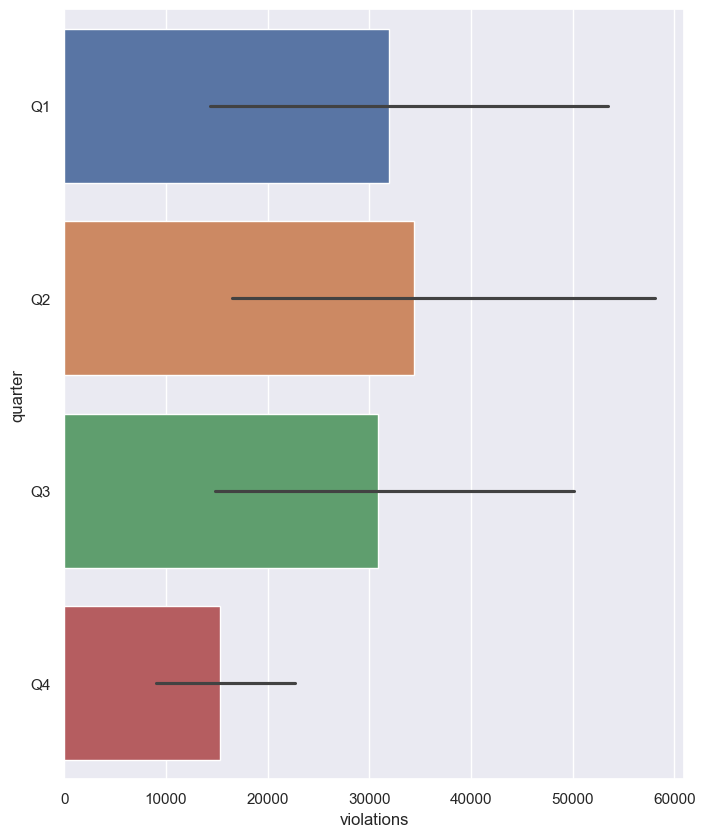

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(data=violations_quarters_df, y="quarter", x="violations", hue="quarter")

<Axes: xlabel='violations', ylabel='quarter'>

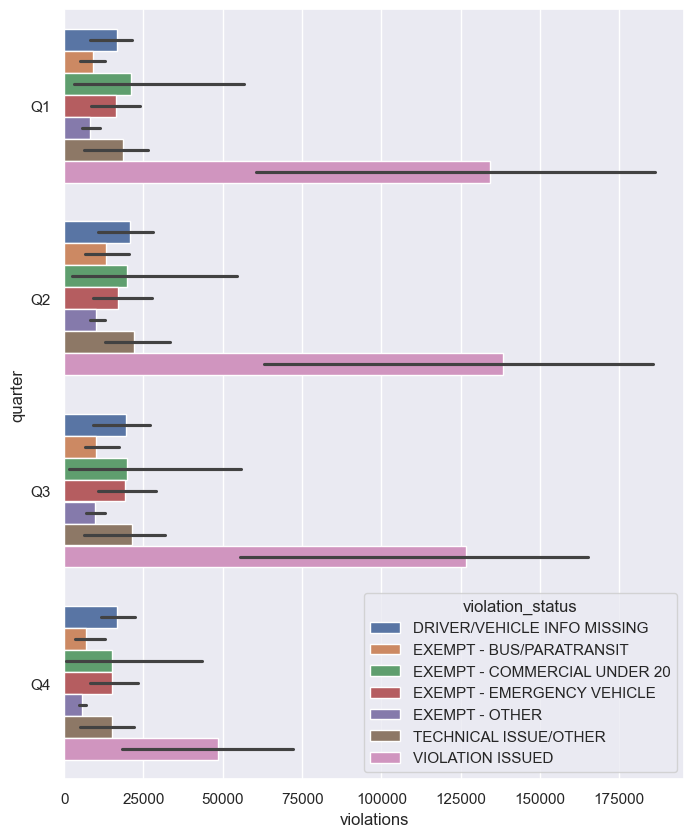

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=violations_quarters_df, y="quarter", x="violations", hue="violation_status"
)

<Axes: xlabel='violations', ylabel='quarter'>

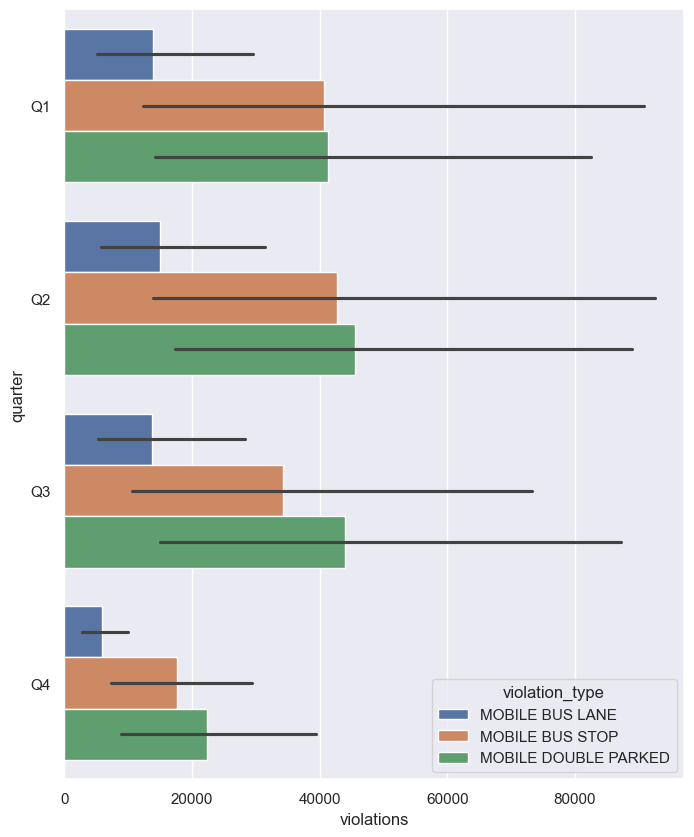

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(
    data=violations_quarters_df, y="quarter", x="violations", hue="violation_type"
)

## Statistical Testing

Dataframes up to date:

- violations_2025_df
- violations_buses_df
- violations_quarters_df


### Recap


In [ ]:
violations_2025_df.head()

,violation_status,violation_type,violations
3,VIOLATION ISSUED,MOBILE BUS STOP,586154
4,VIOLATION ISSUED,MOBILE DOUBLE PARKED,559417
5,VIOLATION ISSUED,MOBILE BUS LANE,197014
6,TECHNICAL ISSUE/OTHER,MOBILE BUS STOP,107039
7,TECHNICAL ISSUE/OTHER,MOBILE DOUBLE PARKED,99429


In [75]:
violations_buses_df.head()

,bus_route_id,violation_status,violation_type,violations,borough
0,BX19,VIOLATION ISSUED,MOBILE DOUBLE PARKED,74749,Bronx
1,M101,VIOLATION ISSUED,MOBILE BUS STOP,64519,Manhattan
2,M101,VIOLATION ISSUED,MOBILE DOUBLE PARKED,59472,Manhattan
3,M100,VIOLATION ISSUED,MOBILE DOUBLE PARKED,55477,Manhattan
4,M15+,VIOLATION ISSUED,MOBILE BUS STOP,49793,Manhattan


In [76]:
violations_quarters_df.head()

,quarter,violation_status,violation_type,violations
0,Q1,DRIVER/VEHICLE INFO MISSING,MOBILE BUS LANE,8200
1,Q1,DRIVER/VEHICLE INFO MISSING,MOBILE BUS STOP,21407
2,Q1,DRIVER/VEHICLE INFO MISSING,MOBILE DOUBLE PARKED,20735
3,Q1,EXEMPT - BUS/PARATRANSIT,MOBILE BUS LANE,4957
4,Q1,EXEMPT - BUS/PARATRANSIT,MOBILE BUS STOP,12739


In [ ]:
violations_2025_df["violation_status"].nunique

<bound method IndexOpsMixin.nunique of 3                 VIOLATION ISSUED
4                 VIOLATION ISSUED
5                 VIOLATION ISSUED
6            TECHNICAL ISSUE/OTHER
7            TECHNICAL ISSUE/OTHER
8            TECHNICAL ISSUE/OTHER
9                   EXEMPT - OTHER
10                  EXEMPT - OTHER
11                  EXEMPT - OTHER
12      EXEMPT - EMERGENCY VEHICLE
13      EXEMPT - EMERGENCY VEHICLE
14      EXEMPT - EMERGENCY VEHICLE
15    EXEMPT - COMMERCIAL UNDER 20
16    EXEMPT - COMMERCIAL UNDER 20
17    EXEMPT - COMMERCIAL UNDER 20
18        EXEMPT - BUS/PARATRANSIT
19        EXEMPT - BUS/PARATRANSIT
20        EXEMPT - BUS/PARATRANSIT
21     DRIVER/VEHICLE INFO MISSING
22     DRIVER/VEHICLE INFO MISSING
23     DRIVER/VEHICLE INFO MISSING
Name: violation_status, dtype: object>

### T-Tests


In [ ]:
status_groups = [
    violations_2025_df[violations_2025_df["violation_status"] == status]["violations"]
    for status in violations_2025_df["violation_status"].unique()
]
stats.f_oneway(*status_groups)

F_onewayResult(statistic=np.float64(6.902405021735706), pvalue=np.float64(0.0014368114986054296))

In [ ]:
type_groups = [
    violations_2025_df[violations_2025_df["violation_type"] == v_type]["violations"]
    for v_type in violations_2025_df["violation_type"].unique()
]
stats.f_oneway(*type_groups)

F_onewayResult(statistic=np.float64(0.8998467521487435), pvalue=np.float64(0.424156706626369))

In [ ]:
boro_groups = [
    violations_buses_df[violations_buses_df["borough"] == boro]["violations"]
    for boro in violations_buses_df["borough"].unique()
]
stats.f_oneway(*boro_groups)

F_onewayResult(statistic=np.float64(2.3201901838069485), pvalue=np.float64(0.055232827760711006))

In [ ]:
quarter_groups = [
    violations_quarters_df[violations_quarters_df["quarter"] == qtr]["violations"]
    for qtr in violations_quarters_df["quarter"].unique()
]
stats.f_oneway(*quarter_groups)

F_onewayResult(statistic=np.float64(0.9831375164648742), pvalue=np.float64(0.4047689708844542))